<a href="https://colab.research.google.com/github/asurovi/Summer-School-on-ML-for-Electron-Microscopy-2026/blob/main/4PM_hackaton_Agentic_analysis_AgnilaGhoshSurovi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# STEM Image-Analysis Agent (smolagents + Gemini)

This notebook provides a sandbox for designing a simple image-analysis agent for **STEM HAADF** data.

The agent is structured using the **smolagents** Python framework. Documentation is available here: https://huggingface.co/docs/smolagents/en/index

As a starting point, several basic image-analysis tools are provided, including load_image, denoise, contrast enhancement, and get_statistics.

The **gemini/gemini-3.1-flash-lite** model is used as the reasoning core and is accessed through the API.

## 1. Install dependencies and upload data

In [ ]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "smolagents[litellm]", "scikit-image", "h5py", "gdown", "scifireaders"], check=True)

import h5py
import numpy as np
import json
import matplotlib.pyplot as plt
import SciFiReaders

In [ ]:
# ---- HDF5 loader ----
def load_hdf5_to_dict(file_path):
    with h5py.File(file_path, "r") as f:
        return _load_item(f)

def _load_item(obj):
    if isinstance(obj, h5py.Group):
        keys = list(obj.keys())
        if len(keys) == 0 and "value" not in obj.attrs:
            return {}
        if all(k.isdigit() for k in keys):
            return [_load_item(obj[k]) for k in sorted(keys, key=lambda x: int(x))]
        out = {k: _load_item(obj[k]) for k in keys}
        if "value" in obj.attrs and obj.attrs["value"] == "None":
            return None
        return out
    elif isinstance(obj, h5py.Dataset):
        data = obj[()]
        if np.isscalar(data):
            return data
        if isinstance(data, (bytes, np.bytes_)):
            try:    return json.loads(data.decode())
            except: return data.decode()
        if data.dtype.kind == "S":
            try:    return [json.loads(x.decode()) for x in data]
            except: return [x.decode() for x in data]
        return data
    raise ValueError("Unknown HDF5 object type:", obj)

# ---- download (gdown, --fuzzy resolves the share links) ----
!gdown https://drive.google.com/file/d/14N5Vg7Baqj2OdvgTD1l9oaWWvNvPCpYs/view?usp=drive_link --fuzzy
!gdown https://drive.google.com/file/d/1IB2Au4Dh7iNZCeOmj1dmaGB2JOIFAxoN/view?usp=drive_link --fuzzy
!gdown https://drive.google.com/file/d/1UP367K9vBi0yEY1cKt9a5p7ZxQu2GjOa/view?usp=sharing --fuzzy

data      = load_hdf5_to_dict("/content/graphene_2.h5")
data1     = SciFiReaders.EMDReader("/content/0174 - 10.5 Mx STEM.emd").read()
data_more = load_hdf5_to_dict("/content/HAADF_21.h5")

im0 = np.asarray(data["Measurement_000"]["Channel_000"]["HAADF"]["HAADF"])[:1000, :1000]
im1 = data1['Channel_004'].compute().mean(0)
im2 = np.asarray(data_more["Measurement_000"]["Channel_000"]["HAADF"]["HAADF"])
IMAGES = [im0, im1, im2]

Downloading...
From: https://drive.google.com/uc?id=14N5Vg7Baqj2OdvgTD1l9oaWWvNvPCpYs
To: /content/graphene_2.h5
100% 17.1M/17.1M [00:00<00:00, 136MB/s] 
Downloading...
From: https://drive.google.com/uc?id=1IB2Au4Dh7iNZCeOmj1dmaGB2JOIFAxoN
To: /content/HAADF_21.h5
100% 4.53M/4.53M [00:00<00:00, 67.3MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1UP367K9vBi0yEY1cKt9a5p7ZxQu2GjOa
From (redirected): https://drive.google.com/uc?id=1UP367K9vBi0yEY1cKt9a5p7ZxQu2GjOa&confirm=t&uuid=6dde7880-c772-491f-b40f-069d842ddbe5
To: /content/0174 - 10.5 Mx STEM.emd
100% 1.01G/1.01G [00:09<00:00, 108MB/s]


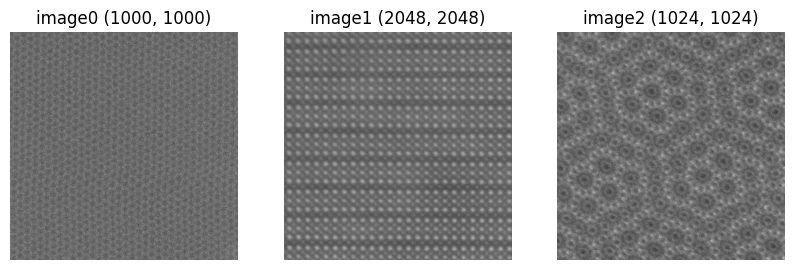

loaded 3 STEM images


In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(10, 4))
for i, im in enumerate(IMAGES):
    ax[i].imshow(im, cmap="gray"); ax[i].set_title(f"image{i} {im.shape}"); ax[i].axis("off")
plt.show()
print("loaded", len(IMAGES), "STEM images")

## 3. The image-analysis tools


In [ ]:
#@title auxilary


from scipy.ndimage import gaussian_filter, median_filter, convolve
from skimage.restoration import denoise_tv_chambolle, denoise_nl_means
from skimage.exposure import equalize_adapthist, equalize_hist, rescale_intensity
from smolagents import tool

STATE   = {"img": None, "name": None}   # the current working image
RESULTS = {}                            # name -> processed array, retrievable in Python
SHOW    = True                          # display each tool's result inline

def _to_float(a):
    a = np.asarray(a, float)
    lo, hi = np.percentile(a, [0.5, 99.5])
    if hi <= lo: hi = lo + 1.0
    return np.clip((a - lo) / (hi - lo), 0, 1)

# Immerker (1996) noise-sigma estimate -> dependency-free SNR
_M = np.array([[1, -2, 1], [-2, 4, -2], [1, -2, 1]], float)
def _noise_sigma(f):
    H, W = f.shape
    return float(np.sqrt(np.pi / 2) * np.sum(np.abs(convolve(f, _M))) / (6 * (W - 2) * (H - 2)))
def _snr_db(f):
    return float(20 * np.log10((f.std() + 1e-9) / (_noise_sigma(f) + 1e-9)))

def _show(img, title):
    if not SHOW: return
    plt.figure(figsize=(4.5, 4.5)); plt.imshow(img, cmap="gray")
    plt.title(title); plt.axis("off"); plt.show()

def _store(name, arr, title):
    "Make arr the current image, keep a named copy in RESULTS, and display it."
    STATE["img"], STATE["name"] = arr, name
    RESULTS[name] = arr
    _show(arr, title)
    return name

def get_image(name=None):
    "Return a processed array by name (default: the current image); see list_results()."
    return STATE["img"] if name is None else RESULTS.get(name)

def list_results():
    "Names of every array produced so far, oldest first."
    return list(RESULTS)

Below are examples of the different tools available to the agent. The docstrings are used to provide context and instructions for how the agent should use each tool.

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

from smolagents import tool
from scipy.ndimage import gaussian_filter, median_filter
from skimage.restoration import denoise_tv_chambolle, denoise_nl_means
from skimage.exposure import equalize_adapthist, equalize_hist, rescale_intensity


# -----------------------------
# Small helpers for unified tools
# -----------------------------

def _current_image():
    """Return the current image or None."""
    return STATE.get("img", None)


def _current_name():
    """Return current image name."""
    return STATE.get("name", "current_image")


def _validate_current_image():
    """Return (ok, image_or_message)."""
    f = _current_image()
    if f is None:
        return False, "No image loaded. Call load_image(index) first."
    return True, np.asarray(f, dtype=float)


def _safe_float(x):
    """Convert NumPy scalar to plain Python float."""
    return float(np.asarray(x))


def _format_shape(arr):
    """Format image shape as text."""
    return f"{arr.shape[0]} x {arr.shape[1]} px"


# -----------------------------
# Image loading / state tools
# -----------------------------

@tool
def list_images() -> str:
    """
    List available STEM images with their index and pixel shape.

    Returns:
        Text list of available images.
    """
    if len(IMAGES) == 0:
        return "No images are available."

    lines = ["Available STEM images:"]
    for i, im in enumerate(IMAGES):
        arr = np.asarray(im)
        lines.append(f"  index {i}: shape {arr.shape}")

    return "\n".join(lines)


@tool
def load_image(index: int) -> str:
    """
    Load an available STEM image and make it the current image.

    Args:
        index: Image index from 0 to len(IMAGES)-1.

    Returns:
        Status message with image shape, noise estimate, and SNR.
    """
    if len(IMAGES) == 0:
        return "No images are available."

    if not isinstance(index, int):
        return "Invalid index. The index must be an integer."

    if not (0 <= index < len(IMAGES)):
        return f"Invalid index {index}. Available image indices are 0..{len(IMAGES) - 1}."

    f = _to_float(IMAGES[index])
    name = _store(f"image{index}", f, f"image{index} loaded")

    return (
        f"Loaded image {index} as current image '{name}'. "
        f"Shape: {_format_shape(f)}. "
        f"SNR: {_snr_db(f):.2f} dB."
    )


# -----------------------------
# Analysis tools
# -----------------------------

@tool
def get_image_stats() -> str:
    """
    Calculate basic statistics for the current STEM image.

    Returns:
        Text summary with shape, intensity statistics, noise estimate, and SNR.
    """
    ok, result = _validate_current_image()
    if not ok:
        return result

    f = result

    return (
        f"Statistics for current image '{_current_name()}': "
        f"shape {_format_shape(f)}, "
        f"mean {_safe_float(np.nanmean(f)):.4f}, "
        f"std {_safe_float(np.nanstd(f)):.4f}, "
        f"min {_safe_float(np.nanmin(f)):.4f}, "
        f"max {_safe_float(np.nanmax(f)):.4f}, "
        f"median {_safe_float(np.nanmedian(f)):.4f}, "
        f"p01 {_safe_float(np.nanpercentile(f, 1)):.4f}, "
        f"p99 {_safe_float(np.nanpercentile(f, 99)):.4f}, "
        f"SNR {_snr_db(f):.2f} dB."
    )


@tool
def make_fft(null_dc: bool = True, dc_radius: int = 3) -> str:
    """
    Calculate the 2D FFT log-magnitude image for the current STEM image.

    Args:
        null_dc: Whether to suppress the central DC peak before estimating the dominant period.
        dc_radius: Radius in pixels around the FFT center to suppress when null_dc is true.

    Returns:
        Status message with estimated dominant period and stored FFT result name.
    """
    ok, result = _validate_current_image()
    if not ok:
        return result

    f = result
    H, W = f.shape

    # Remove mean before FFT to reduce the DC component.
    centered = f - np.nanmean(f)

    F = np.fft.fftshift(np.abs(np.fft.fft2(centered)))
    logF = np.log1p(F)

    cy, cx = H // 2, W // 2
    F_for_peak = F.copy()

    if null_dc:
        r = max(1, int(dc_radius))
        y0, y1 = max(0, cy - r), min(H, cy + r + 1)
        x0, x1 = max(0, cx - r), min(W, cx + r + 1)
        F_for_peak[y0:y1, x0:x1] = 0

    py, px = np.unravel_index(np.argmax(F_for_peak), F_for_peak.shape)
    freq_px = np.hypot(py - cy, px - cx)
    dominant_period_px = min(H, W) / freq_px if freq_px > 0 else float("inf")

    result_name = f"{_current_name()}|fft_log"
    RESULTS[result_name] = logF

    if SHOW:
        fig, ax = plt.subplots(1, 2, figsize=(8, 4))
        ax[0].imshow(f, cmap="gray")
        ax[0].set_title("current image")
        ax[0].axis("off")

        ax[1].imshow(logF, cmap="magma")
        ax[1].set_title("log |FFT|")
        ax[1].axis("off")

        plt.tight_layout()
        plt.show()

    return (
        f"FFT calculated for current image '{_current_name()}'. "
        f"FFT log-magnitude stored in RESULTS as '{result_name}'. "
        f"Dominant FFT peak at pixel offset ({py - cy}, {px - cx}). "
        f"Estimated dominant period: {dominant_period_px:.2f} px."
    )


# -----------------------------
# Image processing tools
# -----------------------------

@tool
def denoise_image(method: str = "tv", strength: float = 1.0) -> str:
    """
    Denoise the current STEM image and make the denoised result the new current image.

    Args:
        method: Denoising method. Use one of: gaussian, median, tv, nlmeans.
        strength: Denoising strength. Larger values produce smoother images. Typical range is 0.5 to 3.

    Returns:
        Status message with before/after noise estimate and SNR.
    """
    ok, result = _validate_current_image()
    if not ok:
        return result

    f = result
    method = method.lower().strip()

    try:
        strength = float(strength)
    except Exception:
        return "Invalid strength. Strength must be a number."

    strength = max(0.0, strength)

    noise_before = _noise_sigma(f)

    if method == "gaussian":
        sigma = max(0.3, strength)
        d = gaussian_filter(f, sigma=sigma)

    elif method == "median":
        size = max(2, int(round(strength)) + 1)
        d = median_filter(f, size=size)

    elif method == "tv":
        weight = 0.05 * max(0.1, strength)
        d = denoise_tv_chambolle(f, weight=weight)

    elif method == "nlmeans":
        sigma_est = max(1e-6, _noise_sigma(f))
        h = max(1e-3, strength * sigma_est)
        d = denoise_nl_means(
            f,
            h=h,
            fast_mode=True,
            patch_size=5,
            patch_distance=6,
        )

    else:
        return "Unknown denoising method. Use one of: gaussian, median, tv, nlmeans."

    name = _store(
        f"{_current_name()}+denoise_{method}",
        d,
        f"denoised using {method}, strength={strength}",
    )

    noise_after = _noise_sigma(d)

    return (
        f"Denoising complete. "
        f"Method: {method}. Strength: {strength}. "
        f"Noise sigma: {noise_before:.4f} -> {noise_after:.4f}. "
        f"SNR after denoising: {_snr_db(d):.2f} dB. "
        f"Result stored as current image '{name}'."
    )


@tool
def enhance_contrast(method: str = "clahe", clip_limit: float = 0.02) -> str:
    """
    Enhance contrast of the current STEM image and make the enhanced result the new current image.

    Args:
        method: Contrast method. Use one of: clahe, equalize, stretch.
        clip_limit: CLAHE clip limit. Typical range is 0.01 to 0.05. Ignored for equalize and stretch.

    Returns:
        Status message with before/after contrast estimate.
    """
    ok, result = _validate_current_image()
    if not ok:
        return result

    f = result
    method = method.lower().strip()

    try:
        clip_limit = float(clip_limit)
    except Exception:
        return "Invalid clip_limit. clip_limit must be a number."

    std_before = np.nanstd(f)

    # Normalize to [0, 1] for stable contrast operations.
    f01 = rescale_intensity(f, in_range="image", out_range=(0, 1))

    if method == "clahe":
        clip_limit = float(np.clip(clip_limit, 0.001, 0.2))
        d = equalize_adapthist(f01, clip_limit=clip_limit)

    elif method == "equalize":
        d = equalize_hist(f01)

    elif method == "stretch":
        p2, p98 = np.nanpercentile(f, [2, 98])
        if p98 <= p2:
            return "Cannot apply contrast stretching because image percentiles are degenerate."
        d = rescale_intensity(f, in_range=(p2, p98), out_range=(0, 1))

    else:
        return "Unknown contrast method. Use one of: clahe, equalize, stretch."

    name = _store(
        f"{_current_name()}+contrast_{method}",
        d,
        f"contrast enhanced using {method}",
    )

    std_after = np.nanstd(d)

    return (
        f"Contrast enhancement complete. "
        f"Method: {method}. "
        f"Intensity std: {std_before:.4f} -> {std_after:.4f}. "
        f"Result stored as current image '{name}'."
    )


# -----------------------------
# Tool list
# -----------------------------

STEM_IMAGE_TOOLS = [
    list_images,
    load_image,
    get_image_stats,
    make_fft,
    denoise_image,
    enhance_contrast,
]

print("tools ready:", [t.name for t in STEM_IMAGE_TOOLS])

tools ready: ['list_images', 'load_image', 'get_image_stats', 'make_fft', 'denoise_image', 'enhance_contrast']


## 4.LLM Model — Gemini

Get a free key at **https://aistudio.google.com/apikey**, then add it as a Colab **Secret**: key icon in the left sidebar -> **Add new secret** -> name `GEMINI_API_KEY`, paste the value, enable **Notebook access**.

In [ ]:
import os
key = os.environ.get("GEMINI_API_KEY")
if not key:
    try:
        from google.colab import userdata
        key = userdata.get("GEMINI_API_KEY")
    except Exception:
        key = None
assert key, ("No GEMINI_API_KEY found. Get a free key at https://aistudio.google.com/apikey, "
             "then add it as a Colab Secret named GEMINI_API_KEY (key icon -> enable Notebook access).")
os.environ["GEMINI_API_KEY"] = key

from smolagents import LiteLLMModel
# temperature=0 -> deterministic tool calls; requests_per_minute keeps us under the free tier.
model = LiteLLMModel(model_id="gemini/gemini-3.1-flash-lite",
                     api_key=key,
                     requests_per_minute=12,
                     verbosity_level=0,)

## 5. Build the agent

A `ToolCallingAgent`. Tools share the current image, so the agent can chain steps. `ask("...")` sends one request.

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ List the available images, then load image 0 and report its SNR.                                                │
│                                                                                                                 │
╰─ LiteLLMModel - gemini/gemini-3.1-flash-lite ───────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Calling tool: 'list_images' with arguments: {}                                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Observations: Available STEM images:
  index 0: shape (1000, 1000)
  index 1: shape (2048, 2048)
  index 2: shape (1024, 1024)

[Step 1: Duration 5.89 seconds| Input tokens: 2,012 | Output tokens: 10]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 2 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Calling tool: 'load_image' with arguments: {'index': 0}                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

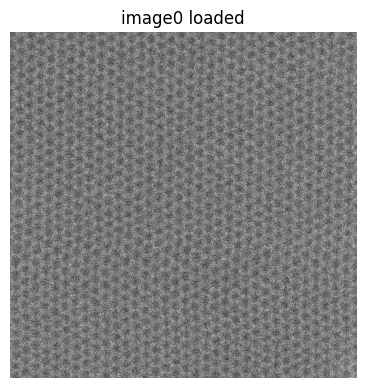

Observations: Loaded image 0 as current image 'image0'. Shape: 1000 x 1000 px. SNR: 0.31 dB.

[Step 2: Duration 1.07 seconds| Input tokens: 4,182 | Output tokens: 24]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 3 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Calling tool: 'final_answer' with arguments: {'answer': "The available images are: index 0 (1000, 1000), index  │
│ 1 (2048, 2048), and index 2 (1024, 1024). Image 0 was loaded, and its SNR is 0.31 dB.\n\ntools_used:            │
│ ['list_images', 'load_image']\nmeasured_values: {'image_0_snr': '0.31 dB'}\ninterpretation: The SNR of image 0  │
│ is 0.31 dB, which indicates a very low signal-to-noise ratio."}                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Observations: The available images are: index 0 (1000, 1000), index 1 (2048, 2048), and index 2 (1024, 1024). Image
0 was loaded, and its SNR is 0.31 dB.

tools_used: |'list_images', 'load_image']
measured_values: {'image_0_snr': '0.31 dB'}
interpretation: The SNR of image 0 is 0.31 dB, which indicates a very low signal-to-noise ratio.

Final answer: The available images are: index 0 (1000, 1000), index 1 (2048, 2048), and index 2 (1024, 1024). Image
0 was loaded, and its SNR is 0.31 dB.

tools_used: ['list_images', 'load_image']
measured_values: {'image_0_snr': '0.31 dB'}
interpretation: The SNR of image 0 is 0.31 dB, which indicates a very low signal-to-noise ratio.

[Step 3: Duration 4.74 seconds| Input tokens: 6,485 | Output tokens: 171]

The available images are: index 0 (1000, 1000), index 1 (2048, 2048), and index 2 (1024, 1024). Image 0 was loaded, and its SNR is 0.31 dB.

tools_used: ['list_images', 'load_image']
measured_values: {'image_0_snr': '0.31 dB'}
interpretation: The SNR of image 0 is 0.31 dB, which indicates a very low signal-to-noise ratio.


In [ ]:
from smolagents import ToolCallingAgent

TOOLS = STEM_IMAGE_TOOLS #define

INSTRUCTIONS = (
    "You are an assistant for analysing STEM images. "
    "Use ONLY the provided tools and choose the fewest calls that satisfy the request. "
    "Base every number on an actual tool result. Do not invent values. "
    "At the end, return a short structured text summary with exactly three sections: "
    "tools_used: a Python-style list of tool names that were called; "
    "measured_values: a JSON-like dictionary containing only values returned by tools; "
    "interpretation: one or two short sentences based only on the measured values."
)

agent = ToolCallingAgent(tools=TOOLS,
                         model=model,
                         add_base_tools=False,
                         max_steps=6,
                         verbosity_level=1,
                         instructions=INSTRUCTIONS)

def ask(query):
    "Send one natural-language image-analysis request to the agent."
    return agent.run(query)

print(ask("List the available images, then load image 0 and report its SNR."))

## 6. Example commands
Run one at a time on the free tier. Each tool also shows its output image as it runs.

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Get a basic statistic for the image 0                                                                           │
│                                                                                                                 │
╰─ LiteLLMModel - gemini/gemini-3.1-flash-lite ───────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Calling tool: 'load_image' with arguments: {'index': 0}                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

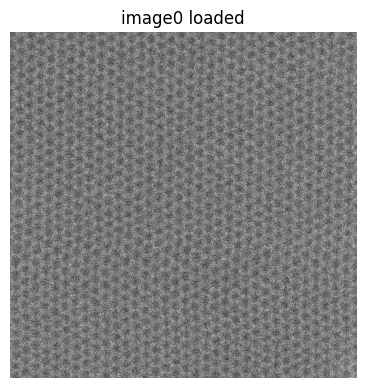

Observations: Loaded image 0 as current image 'image0'. Shape: 1000 x 1000 px. SNR: 0.31 dB.

[Step 1: Duration 1.05 seconds| Input tokens: 2,006 | Output tokens: 14]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 2 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Calling tool: 'get_image_stats' with arguments: {}                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Observations: Statistics for current image 'image0': shape 1000 x 1000 px, mean 0.4689, std 0.1930, min 0.0000, max
1.0000, median 0.4636, p01 0.0410, p99 0.9442, SNR 0.31 dB.

...

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Calling tool: 'final_answer' with arguments: {'answer': "The statistics for image 0 are: shape 1000 x 1000 px,  │
│ mean 0.4689, std 0.1930, min 0.0000, max 1.0000, median 0.4636, p01 0.0410, p99 0.9442, and SNR 0.31            │
│ dB.\n\ntools_used: ['load_image', 'get_image_stats']\nmeasured_values: {'shape': [1000, 1000], 'mean': 0.4689,  │
│ 'std': 0.193, 'min': 0.0, 'max': 1.0, 'median': 0.4636, 'p01': 0.041, 'p99': 0.9442, 'SNR':                     │
│ 0.31}\ninterpretation: The image has a standard deviation of 0.1930 and a low SNR of 0.31 dB, indicating        │
│ significant noise."}                                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Observations: The statistics for image 0 are: shape 1000 x 1000 px, mean 0.4689, std 0.1930, min 0.0000, max 
1.0000, median 0.4636, p01 0.0410, p99 0.9442, and SNR 0.31 dB.

tools_used: |'load_image', 'get_image_stats']
measured_values: {'shape': |1000, 1000], 'mean': 0.4689, 'std': 0.193, 'min': 0.0, 'max': 1.0, 'median': 0.4636, 
'p01': 0.041, 'p99': 0.9442, 'SNR': 0.31}
interpretation: The image has a standard deviation of 0.1930 and a low SNR of 0.31 dB, indicating significant 
noise.

Final answer: The statistics for image 0 are: shape 1000 x 1000 px, mean 0.4689, std 0.1930, min 0.0000, max 
1.0000, median 0.4636, p01 0.0410, p99 0.9442, and SNR 0.31 dB.

tools_used: ['load_image', 'get_image_stats']
measured_values: {'shape': [1000, 1000], 'mean': 0.4689, 'std': 0.193, 'min': 0.0, 'max': 1.0, 'median': 0.4636, 
'p01': 0.041, 'p99': 0.9442, 'SNR': 0.31}
interpretation: The image has a standard deviation of 0.1930 and a low SNR of 0.31 dB, indicating significant 
noise.

[Step 3: Duration 8.20 seconds| Input tokens: 6,496 | Output tokens: 291]

The statistics for image 0 are: shape 1000 x 1000 px, mean 0.4689, std 0.1930, min 0.0000, max 1.0000, median 0.4636, p01 0.0410, p99 0.9442, and SNR 0.31 dB.

tools_used: ['load_image', 'get_image_stats']
measured_values: {'shape': [1000, 1000], 'mean': 0.4689, 'std': 0.193, 'min': 0.0, 'max': 1.0, 'median': 0.4636, 'p01': 0.041, 'p99': 0.9442, 'SNR': 0.31}
interpretation: The image has a standard deviation of 0.1930 and a low SNR of 0.31 dB, indicating significant noise.


In [ ]:
print(ask("Get a basic statistic for the image 0"))

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ How many atoms are on image 0?                                                                                  │
│                                                                                                                 │
╰─ LiteLLMModel - gemini/gemini-3.1-flash-lite ───────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Calling tool: 'load_image' with arguments: {'index': 0}                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

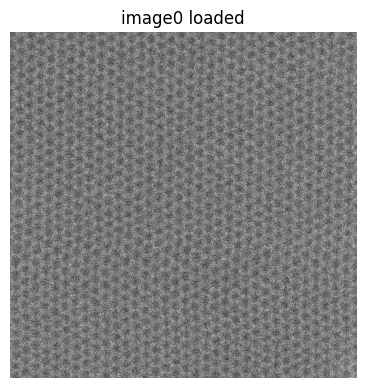

Observations: Loaded image 0 as current image 'image0'. Shape: 1000 x 1000 px. SNR: 0.31 dB.

[Step 1: Duration 1.30 seconds| Input tokens: 2,006 | Output tokens: 14]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 2 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Calling tool: 'make_fft' with arguments: {'null_dc': True}                                                      │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

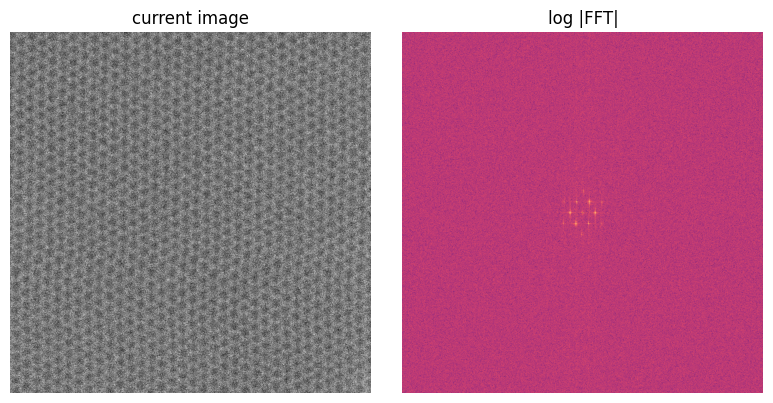

Observations: FFT calculated for current image 'image0'. FFT log-magnitude stored in RESULTS as 'image0|fft_log'. 
Dominant FFT peak at pixel offset (-30, -16). Estimated dominant period: 29.41 px.

[Step 2: Duration 12.38 seconds| Input tokens: 4,151 | Output tokens: 30]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 3 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Calling tool: 'get_image_stats' with arguments: {}                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Observations: Statistics for current image 'image0': shape 1000 x 1000 px, mean 0.4689, std 0.1930, min 0.0000, max
1.0000, median 0.4636, p01 0.0410, p99 0.9442, SNR 0.31 dB.

...

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Calling tool: 'final_answer' with arguments: {'answer': "Based on the FFT analysis, the image shows a periodic  │
│ atomic structure with a dominant period of approximately 29.41 pixels. Given the image size of 1000 x 1000      │
│ pixels, there are approximately (1000 / 29.41) * (1000 / 29.41) ≈ 1157 atoms in the image.\n\ntools_used:       │
│ ['load_image', 'make_fft', 'get_image_stats']\nmeasured_values: {'image_shape': [1000, 1000],                   │
│ 'dominant_period_pixels': 29.41}\ninterpretation: The image consists of a periodic array of atoms with a        │
│ spacing of about 29.41 pixels, leading to an estimate of approximately 1157 atoms across the 1000x1000 pixel    │
│ area."}                                                                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Observations: Based on the FFT analysis, the image shows a periodic atomic structure with a dominant period of 
approximately 29.41 pixels. Given the image size of 1000 x 1000 pixels, there are approximately (1000 / 29.41) * 
(1000 / 29.41) ≈ 1157 atoms in the image.

tools_used: |'load_image', 'make_fft', 'get_image_stats']
measured_values: {'image_shape': |1000, 1000], 'dominant_period_pixels': 29.41}
interpretation: The image consists of a periodic array of atoms with a spacing of about 29.41 pixels, leading to an
estimate of approximately 1157 atoms across the 1000x1000 pixel area.

Final answer: Based on the FFT analysis, the image shows a periodic atomic structure with a dominant period of 
approximately 29.41 pixels. Given the image size of 1000 x 1000 pixels, there are approximately (1000 / 29.41) * 
(1000 / 29.41) ≈ 1157 atoms in the image.

tools_used: ['load_image', 'make_fft', 'get_image_stats']
measured_values: {'image_shape': [1000, 1000], 'dominant_period_pixels': 29.41}
interpretation: The image consists of a periodic array of atoms with a spacing of about 29.41 pixels, leading to an
estimate of approximately 1157 atoms across the 1000x1000 pixel area.

[Step 4: Duration 3.40 seconds| Input tokens: 8,943 | Output tokens: 253]

Based on the FFT analysis, the image shows a periodic atomic structure with a dominant period of approximately 29.41 pixels. Given the image size of 1000 x 1000 pixels, there are approximately (1000 / 29.41) * (1000 / 29.41) ≈ 1157 atoms in the image.

tools_used: ['load_image', 'make_fft', 'get_image_stats']
measured_values: {'image_shape': [1000, 1000], 'dominant_period_pixels': 29.41}
interpretation: The image consists of a periodic array of atoms with a spacing of about 29.41 pixels, leading to an estimate of approximately 1157 atoms across the 1000x1000 pixel area.


In [ ]:
print(ask("How many atoms are on image 0?"))

# 7. Inspect the current image yourself

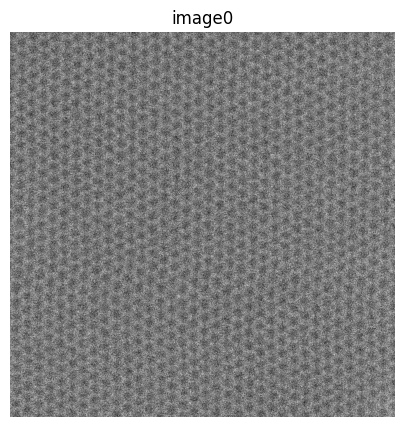

stored results: ['image0', 'image0|fft_log']
current array: ((1000, 1000), dtype('float64'))


In [ ]:
def show_current():
    f = STATE["img"]
    if f is None: print("no current image - run ask('load image 0') first"); return
    plt.figure(figsize=(5, 5)); plt.imshow(f, cmap="gray")
    plt.title(STATE["name"]); plt.axis("off"); plt.show()

def reset(index=0):
    "Reload a clean source image as the current image."
    _store(f"image{index}", _to_float(IMAGES[index]), f"image{index} (reset)")
    print("current image reset to image%d" % index)

show_current()
print("stored results:", list_results())
arr = get_image()                      # the latest cleaned/changed array (NumPy)
print("current array:", None if arr is None else (arr.shape, arr.dtype))

### Equip an agent with tools to:

            a) detect atomic columns,

            b) classify column types,

## Agnila's Agent

In [ ]:
from skimage.feature import peak_local_max
from scipy.ndimage import gaussian_filter
from scipy.spatial import cKDTree
from smolagents import tool
import numpy as np
import matplotlib.pyplot as plt

COLUMN_RESULTS = {}

def _disk_feature_values(img, y, x, radius):
    y0, y1 = max(0, y - radius), min(img.shape[0], y + radius + 1)
    x0, x1 = max(0, x - radius), min(img.shape[1], x + radius + 1)
    yy, xx = np.ogrid[y0:y1, x0:x1]
    mask = (yy - y) ** 2 + (xx - x) ** 2 <= radius ** 2
    return img[y0:y1, x0:x1][mask]

def _annulus_values(img, y, x, inner_radius, outer_radius):
    y0, y1 = max(0, y - outer_radius), min(img.shape[0], y + outer_radius + 1)
    x0, x1 = max(0, x - outer_radius), min(img.shape[1], x + outer_radius + 1)
    yy, xx = np.ogrid[y0:y1, x0:x1]
    rr2 = (yy - y) ** 2 + (xx - x) ** 2
    mask = (rr2 > inner_radius ** 2) & (rr2 <= outer_radius ** 2)
    vals = img[y0:y1, x0:x1][mask]
    return vals if len(vals) else np.array([0.0])

@tool
def detect_atomic_columns(
    min_distance: int = 11,
    spot_sigma: float = 1.8,
    background_sigma: float = 6.0,
    threshold_percentile: float = 98.5,
    max_columns: int = 5000,

) -> str:
    """
    Detect bright atomic columns in the current HAADF STEM image.

    Args:
        min_distance: Minimum allowed separation between detected columns in pixels.
        spot_sigma: Gaussian sigma for atom-sized bright spots.
        background_sigma: Larger Gaussian sigma for background subtraction.
        threshold_percentile: Percentile threshold applied to the Difference-of-Gaussians image.
        max_columns: Maximum number of strongest columns to keep.

    Returns:
        Text summary with number of detected columns and nearest-neighbor spacing estimate.
    """
    ok, result = _validate_current_image()
    if not ok:
        return result
    # Clear downstream results because a new detection invalidates old measurements/classes.
    for key in ["measurements", "labels", "class_feature", "class_centers"]:
        COLUMN_RESULTS.pop(key, None)
    img = _to_float(result)
    min_distance = max(1, int(min_distance))
    max_columns = max(1, int(max_columns))
    threshold_percentile = float(np.clip(threshold_percentile, 0, 100))

    dog = gaussian_filter(img, spot_sigma) - gaussian_filter(img, background_sigma)
    threshold = np.percentile(dog, threshold_percentile)

    positions = peak_local_max(
        dog,
        min_distance=min_distance,
        threshold_abs=threshold,
        exclude_border=min_distance,
    )

    raw_count = len(positions)
    cap_applied = raw_count > max_columns

    if cap_applied:
        strengths = dog[positions[:, 0], positions[:, 1]]
        keep = np.argsort(strengths)[::-1][:max_columns]
        positions = positions[keep]

    strengths = dog[positions[:, 0], positions[:, 1]] if len(positions) else np.array([])

    nn_mean = np.nan
    nn_median = np.nan
    if len(positions) > 2:
        tree = cKDTree(positions)
        dists, _ = tree.query(positions, k=2)
        nn = dists[:, 1]
        nn_mean = float(np.mean(nn))
        nn_median = float(np.median(nn))

    COLUMN_RESULTS["positions_yx"] = positions
    COLUMN_RESULTS["dog"] = dog
    COLUMN_RESULTS["strength"] = strengths

    RESULTS[f"{_current_name()}|dog_column_signal"] = dog

    if SHOW:
        plt.figure(figsize=(6, 6))
        plt.imshow(img, cmap="gray")
        if len(positions):
            plt.scatter(positions[:, 1], positions[:, 0], s=12, facecolors="none", edgecolors="lime")
        plt.title(f"Detected atomic columns: {len(positions)}")
        plt.axis("off")
        plt.show()

    return (
        f"Detected {len(positions)} atomic columns. "
        f"Method: Difference-of-Gaussians plus local maxima. "
        f"Parameters: min_distance={min_distance}, spot_sigma={spot_sigma}, "
        f"background_sigma={background_sigma}, threshold_percentile={threshold_percentile}. "
        f"Mean nearest-neighbor spacing: {nn_mean:.2f} px. "
        f"Median nearest-neighbor spacing: {nn_median:.2f} px."
    )

@tool
def measure_atomic_columns(radius: int = 3, background_inner_radius: int = 5, background_outer_radius: int = 8) -> str:
    """
    Measure local intensity features for detected atomic columns.

    Args:
        radius: Radius in pixels for the column integration disk.
        background_inner_radius: Inner radius of local background annulus.
        background_outer_radius: Outer radius of local background annulus.

    Returns:
        Text summary of measured column intensity features.
    """
    ok, result = _validate_current_image()
    if not ok:
        return result

    img = _to_float(result)
    positions = COLUMN_RESULTS.get("positions_yx")

    if positions is None or len(positions) == 0:
        return "No detected columns. Run detect_atomic_columns first."

    radius = max(1, int(radius))
    background_inner_radius = max(radius + 1, int(background_inner_radius))
    background_outer_radius = max(background_inner_radius + 1, int(background_outer_radius))

    rows = []
    for idx, (y, x) in enumerate(positions):
        y = int(y)
        x = int(x)
        disk_vals = _disk_feature_values(img, y, x, radius)
        bg_vals = _annulus_values(img, y, x, background_inner_radius, background_outer_radius)

        peak = float(img[y, x])
        local_mean = float(np.mean(disk_vals))
        local_sum = float(np.sum(disk_vals))
        bg_median = float(np.median(bg_vals))
        bg_mean = float(np.mean(bg_vals))
        net_sum = float(local_sum - bg_median * len(disk_vals))
        contrast = float(peak - bg_median)

        rows.append({
            "index": idx,
            "y": float(y),
            "x": float(x),
            "peak": peak,
            "local_mean": local_mean,
            "local_sum": local_sum,
            "background_median": bg_median,
            "background_mean": bg_mean,
            "net_integrated": net_sum,
            "local_contrast": contrast,
        })

    COLUMN_RESULTS["measurements"] = rows

    net = np.array([r["net_integrated"] for r in rows])
    peak = np.array([r["peak"] for r in rows])

    return (
        f"Measured {len(rows)} atomic columns. "
        f"Integration radius: {radius} px. "
        f"Net integrated intensity mean={net.mean():.4f}, std={net.std():.4f}, "
        f"min={net.min():.4f}, max={net.max():.4f}. "
        f"Peak intensity mean={peak.mean():.4f}, std={peak.std():.4f}."
    )

@tool
def classify_column_types(n_types: int = 2, feature: str = "net_integrated") -> str:
    """
    Classify detected atomic columns into intensity-based column types.

    Args:
        n_types: Number of column types to classify.
        feature: Measurement feature to cluster. Good choices are net_integrated, peak, local_mean, local_contrast.

    Returns:
        Text summary with class counts and feature centers.
    """
    measurements = COLUMN_RESULTS.get("measurements")
    positions = COLUMN_RESULTS.get("positions_yx")

    if measurements is None or len(measurements) == 0:
        return "No column measurements. Run measure_atomic_columns first."

    if feature not in measurements[0]:
        return f"Unknown feature '{feature}'. Use one of: {list(measurements[0].keys())}"

    n_types = max(1, min(int(n_types), len(measurements)))
    values = np.array([m[feature] for m in measurements], dtype=float).reshape(-1, 1)

    try:
        from sklearn.cluster import KMeans
        km = KMeans(n_clusters=n_types, random_state=0, n_init=10)
        raw_labels = km.fit_predict(values)
        raw_centers = km.cluster_centers_.ravel()
    except Exception:
        # Fallback if sklearn is unavailable: quantile bins.
        edges = np.quantile(values.ravel(), np.linspace(0, 1, n_types + 1))
        raw_labels = np.clip(np.digitize(values.ravel(), edges[1:-1]), 0, n_types - 1)
        raw_centers = np.array([values.ravel()[raw_labels == i].mean() for i in range(n_types)])

    order = np.argsort(raw_centers)
    remap = {old: new for new, old in enumerate(order)}
    labels = np.array([remap[int(label)] for label in raw_labels], dtype=int)
    centers = np.array([raw_centers[old] for old in order], dtype=float)

    for m, label in zip(measurements, labels):
        m["column_type"] = int(label)

    COLUMN_RESULTS["labels"] = labels
    COLUMN_RESULTS["class_feature"] = feature
    COLUMN_RESULTS["class_centers"] = centers

    counts = np.bincount(labels, minlength=n_types)

    ok, result = _validate_current_image()
    if ok and SHOW:
        img = _to_float(result)
        plt.figure(figsize=(6, 6))
        plt.imshow(img, cmap="gray")
        cmap = plt.cm.get_cmap("tab10", n_types)
        for label in range(n_types):
            pts = positions[labels == label]
            if len(pts):
                plt.scatter(
                    pts[:, 1], pts[:, 0],
                    s=18, facecolors="none",
                    edgecolors=[cmap(label)],
                    label=f"type {label}: n={len(pts)}"
                )
        plt.title(f"Column types by {feature}")
        plt.legend(loc="upper right")
        plt.axis("off")
        plt.show()

    summary = ", ".join(
        [f"type {i}: count={int(counts[i])}, center={centers[i]:.4f}" for i in range(n_types)]
    )

    return (
        f"Classified {len(measurements)} atomic columns into {n_types} types using feature '{feature}'. "
        f"Raw candidate peaks before cap: {raw_count}. "
        f"Max-column cap applied: {cap_applied}. "
        f"Types are ordered from lowest to highest feature value. {summary}."
    )

@tool
def summarize_column_analysis() -> str:
    """
    Summarize the current atomic-column detection, measurement, and classification results.

    Returns:
        Compact text report of detected columns and classified types.
    """
    positions = COLUMN_RESULTS.get("positions_yx")
    measurements = COLUMN_RESULTS.get("measurements")
    labels = COLUMN_RESULTS.get("labels")
    centers = COLUMN_RESULTS.get("class_centers")
    feature = COLUMN_RESULTS.get("class_feature")

    if positions is None:
        return "No atomic-column detection has been run yet."

    lines = [f"Atomic-column analysis summary: detected_columns={len(positions)}"]

    if measurements is not None:
        net = np.array([m["net_integrated"] for m in measurements])
        lines.append(
            f"measured_columns={len(measurements)}, "
            f"net_integrated_mean={net.mean():.4f}, net_integrated_std={net.std():.4f}"
        )

    if labels is not None:
        counts = np.bincount(labels)
        class_text = ", ".join(
            [f"type {i}: count={int(counts[i])}, center={centers[i]:.4f}" for i in range(len(counts))]
        )
        lines.append(f"classification_feature={feature}; {class_text}")

    return "\n".join(lines)

# Add the hackathon tools to the existing agent tool list.
new_tools = [
    detect_atomic_columns,
    measure_atomic_columns,
    classify_column_types,
    summarize_column_analysis,
]

tool_by_name = {tool.name: tool for tool in STEM_IMAGE_TOOLS}
for tool in new_tools:
    tool_by_name[tool.name] = tool
STEM_IMAGE_TOOLS = list(tool_by_name.values())

print("updated tools:", [tool.name for tool in STEM_IMAGE_TOOLS])

# Rebuild the agent so it can see the new tools.
try:
    from smolagents import ToolCallingAgent

    TOOLS = STEM_IMAGE_TOOLS

    agent = ToolCallingAgent(
        tools=TOOLS,
        model=model,
        add_base_tools=False,
        max_steps=10,
        verbosity_level=1,
        instructions=INSTRUCTIONS,
    )

    def ask(query):
        return agent.run(query)

    print("Agent rebuilt with atomic-column detection and classification tools.")
except Exception as exc:
    print("Tools are ready, but the agent was not rebuilt:", exc)

updated tools: ['list_images', 'load_image', 'get_image_stats', 'make_fft', 'denoise_image', 'enhance_contrast', 'detect_atomic_columns', 'measure_atomic_columns', 'classify_column_types', 'summarize_column_analysis']
Agent rebuilt with atomic-column detection and classification tools.


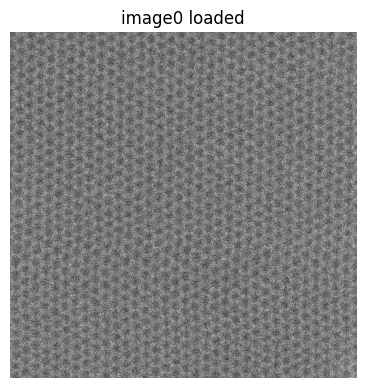

Loaded image 0 as current image 'image0'. Shape: 1000 x 1000 px. SNR: 0.31 dB.


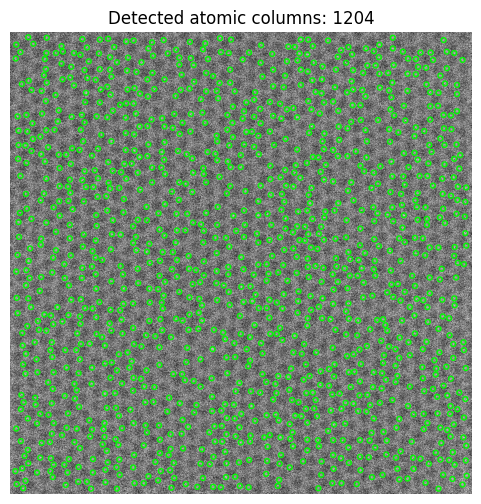

Detected 1204 atomic columns. Method: Difference-of-Gaussians plus local maxima. Parameters: min_distance=11, spot_sigma=1.8, background_sigma=6.0, threshold_percentile=98.5. Mean nearest-neighbor spacing: 19.74 px. Median nearest-neighbor spacing: 18.79 px.


In [ ]:
print(load_image(0))
print(detect_atomic_columns(
    min_distance=11,
    spot_sigma=1.8,
    background_sigma=6.0,
    threshold_percentile=98.5,
    max_columns=5000
))


╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Load image 0. Detect atomic columns with min_distance=11, spot_sigma=1.8, background_sigma=6.0,                 │
│ threshold_percentile=98.5, and max_columns=5000. Then measure the columns with radius=3, classify them into 2   │
│ column types using net_integrated intensity, and summarize the result.                                          │
│                                                                                                                 │
╰─ LiteLLMModel - gemini/gemini-3.1-flash-lite ───────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Calling tool: 'load_image' with arguments: {'index': 0}                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

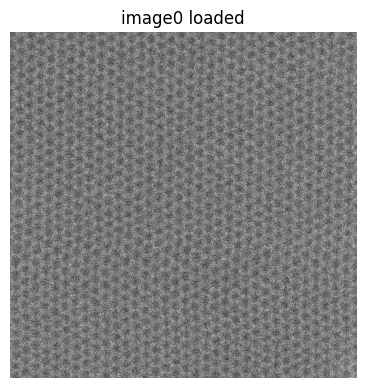

Observations: Loaded image 0 as current image 'image0'. Shape: 1000 x 1000 px. SNR: 0.31 dB.

[Step 1: Duration 1.57 seconds| Input tokens: 2,964 | Output tokens: 14]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 2 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Calling tool: 'detect_atomic_columns' with arguments: {'threshold_percentile': 98.5, 'background_sigma': 6,     │
│ 'max_columns': 5000, 'min_distance': 11, 'spot_sigma': 1.8}                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

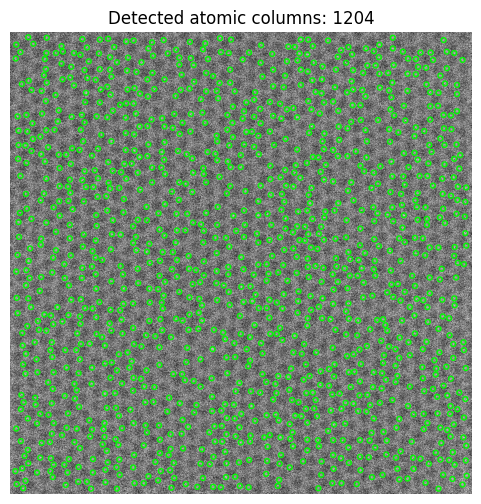

Observations: Detected 1204 atomic columns. Method: Difference-of-Gaussians plus local maxima. Parameters: 
min_distance=11, spot_sigma=1.8, background_sigma=6, threshold_percentile=98.5. Mean nearest-neighbor spacing: 
19.74 px. Median nearest-neighbor spacing: 18.79 px.

[Step 2: Duration 5.78 seconds| Input tokens: 6,070 | Output tokens: 68]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 3 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Calling tool: 'measure_atomic_columns' with arguments: {'radius': 3}                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Observations: Measured 1204 atomic columns. Integration radius: 3 px. Net integrated intensity mean=3.2067, 
std=0.8865, min=0.4217, max=6.1897. Peak intensity mean=0.7045, std=0.1725.

[Step 3: Duration 3.62 seconds| Input tokens: 9,405 | Output tokens: 84]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 4 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Calling tool: 'classify_column_types' with arguments: {'feature': 'net_integrated', 'n_types': 2}               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

/tmp/ipykernel_3290/2300714948.py:234: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", n_types)


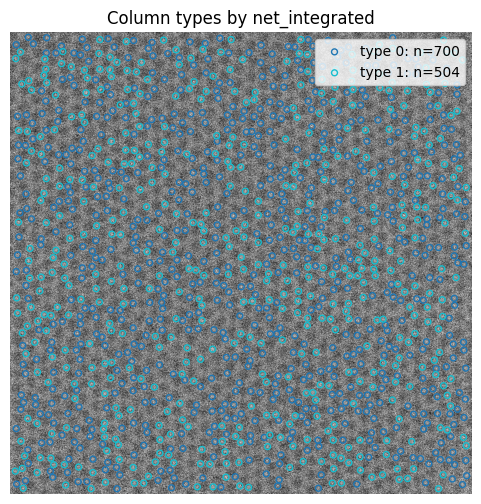

Error executing tool 'classify_column_types' with arguments {'feature': 'net_integrated', 'n_types': 2}: NameError:
name 'raw_count' is not defined
Please try again or use another tool

[Step 4: Duration 5.60 seconds| Input tokens: 12,917 | Output tokens: 110]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 5 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Calling tool: 'classify_column_types' with arguments: {'feature': 'net_integrated', 'n_types': 2}               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

/tmp/ipykernel_3290/2300714948.py:234: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", n_types)


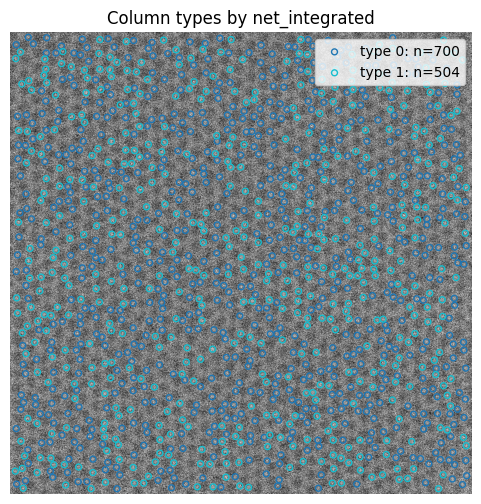

Error executing tool 'classify_column_types' with arguments {'feature': 'net_integrated', 'n_types': 2}: NameError:
name 'raw_count' is not defined
Please try again or use another tool

[Step 5: Duration 4.54 seconds| Input tokens: 16,511 | Output tokens: 136]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 6 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Calling tool: 'summarize_column_analysis' with arguments: {}                                                    │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Observations: Atomic-column analysis summary: detected_columns=1204
measured_columns=1204, net_integrated_mean=3.2067, net_integrated_std=0.8865
classification_feature=net_integrated; type 0: count=700, center=2.6089, type 1: count=504, center=4.0427

...

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Calling tool: 'final_answer' with arguments: {'answer': "The atomic columns in image 0 were successfully        │
│ analyzed. 1204 columns were detected and measured, with a net integrated intensity mean of 3.2067 and standard  │
│ deviation of 0.8865. Classification into two types based on net integrated intensity yielded 700 columns of     │
│ type 0 (center 2.6089) and 504 columns of type 1 (center 4.0427).\n\ntools_used: ['load_image',                 │
│ 'detect_atomic_columns', 'measure_atomic_columns', 'summarize_column_analysis']\nmeasured_values:               │
│ {'detected_columns': 1204, 'net_integrated_mean': 3.2067, 'net_integrated_std': 0.8865,                         │
│ 'classification_type_0_count': 700, 'classification_type_0_center': 2.6089, 'classification_type_1_count': 504, │
│ 'classification_type_1_center': 4.0427}\ninterpretation: The atomic columns are distributed into two distinct   │
│ intensity populations, with type 1 columns being significantly brighter than type 0 columns."}                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Observations: The atomic columns in image 0 were successfully analyzed. 1204 columns were detected and measured, 
with a net integrated intensity mean of 3.2067 and standard deviation of 0.8865. Classification into two types 
based on net integrated intensity yielded 700 columns of type 0 (center 2.6089) and 504 columns of type 1 (center 
4.0427).

tools_used: |'load_image', 'detect_atomic_columns', 'measure_atomic_columns', 'summarize_column_analysis']
measured_values: {'detected_columns': 1204, 'net_integrated_mean': 3.2067, 'net_integrated_std': 0.8865, 
'classification_type_0_count': 700, 'classification_type_0_center': 2.6089, 'classification_type_1_count': 504, 
'classification_type_1_center': 4.0427}
interpretation: The atomic columns are distributed into two distinct intensity populations, with type 1 columns 
being significantly brighter than type 0 columns.

Final answer: The atomic columns in image 0 were successfully analyzed. 1204 columns were detected and measured, 
with a net integrated intensity mean of 3.2067 and standard deviation of 0.8865. Classification into two types 
based on net integrated intensity yielded 700 columns of type 0 (center 2.6089) and 504 columns of type 1 (center 
4.0427).

tools_used: ['load_image', 'detect_atomic_columns', 'measure_atomic_columns', 'summarize_column_analysis']
measured_values: {'detected_columns': 1204, 'net_integrated_mean': 3.2067, 'net_integrated_std': 0.8865, 
'classification_type_0_count': 700, 'classification_type_0_center': 2.6089, 'classification_type_1_count': 504, 
'classification_type_1_center': 4.0427}
interpretation: The atomic columns are distributed into two distinct intensity populations, with type 1 columns 
being significantly brighter than type 0 columns.

[Step 7: Duration 5.73 seconds| Input tokens: 24,057 | Output tokens: 429]

The atomic columns in image 0 were successfully analyzed. 1204 columns were detected and measured, with a net integrated intensity mean of 3.2067 and standard deviation of 0.8865. Classification into two types based on net integrated intensity yielded 700 columns of type 0 (center 2.6089) and 504 columns of type 1 (center 4.0427).

tools_used: ['load_image', 'detect_atomic_columns', 'measure_atomic_columns', 'summarize_column_analysis']
measured_values: {'detected_columns': 1204, 'net_integrated_mean': 3.2067, 'net_integrated_std': 0.8865, 'classification_type_0_count': 700, 'classification_type_0_center': 2.6089, 'classification_type_1_count': 504, 'classification_type_1_center': 4.0427}
interpretation: The atomic columns are distributed into two distinct intensity populations, with type 1 columns being significantly brighter than type 0 columns.


In [ ]:
print(ask(
    "Load image 0. Detect atomic columns with min_distance=11, spot_sigma=1.8, "
    "background_sigma=6.0, threshold_percentile=98.5, and max_columns=5000. "
    "Then measure the columns with radius=3, classify them into 2 column types "
    "using net_integrated intensity, and summarize the result."
))